# Preliminary

In [2]:
# Importing the course packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Importing the course datasets 
climate_change = pd.read_csv('../datasets/climate_change.csv', parse_dates=["date"], index_col="date")
medals = pd.read_csv('../datasets/medals_by_country_2016.csv', index_col=0)
summer_2016 = pd.read_csv('../datasets/summer2016.csv')
austin_weather = pd.read_csv("../datasets/austin_weather.csv", index_col="DATE")
weather = pd.read_csv("../datasets/seattle_weather.csv", index_col="DATE")

# Some pre-processing on the weather datasets, including adding a month column
seattle_weather = weather[weather["STATION"] == "USW00094290"] 
month = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"] 
seattle_weather["MONTH"] = month 
austin_weather.loc[:,"MONTH"] = month

C:\Users\lucfi\AppData\Local\Temp\ipykernel_23288\3514698148.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seattle_weather["MONTH"] = month


# Bar Charts

In [2]:
medals.head()

,Bronze,Gold,Silver
United States,67,137,52
Germany,67,47,43
Great Britain,26,64,55
Russia,35,50,28
China,35,44,30


## Visualizing Olympic Medals data

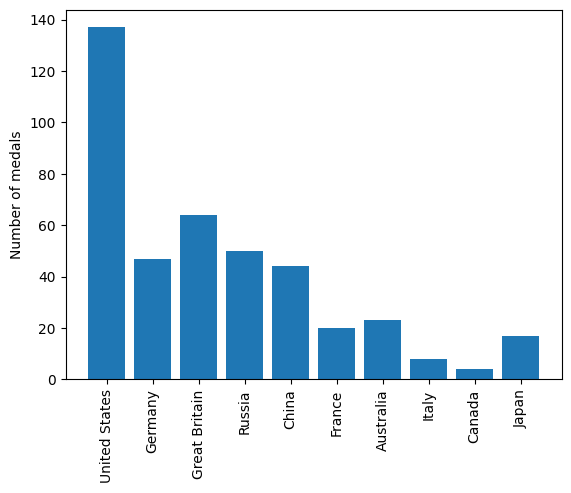

In [14]:
fig, ax = plt.subplots()
ax.bar(medals.index, medals["Gold"])
# Rotate labels 90 degrees to avoid overlap
ax.tick_params(axis='x', rotation=90)  # Use tick_params INSTEAD of set_xticklabels
ax.set_ylabel("Number of medals")
plt.show()

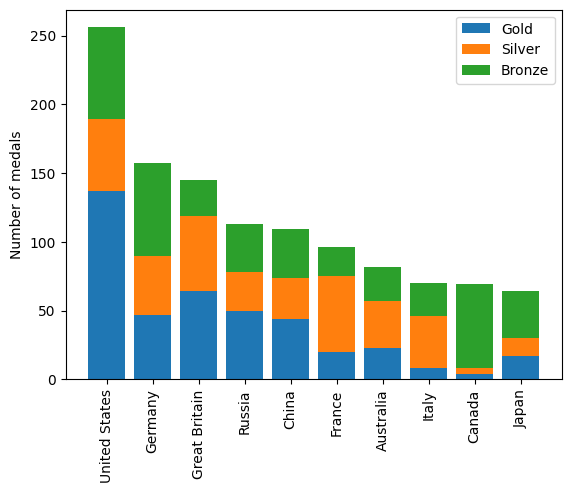

In [25]:
# Stacked bar chart -> just do multiple "ax.bar" calls
fig, ax = plt.subplots()
ax.bar(medals.index, medals["Gold"],label = "Gold")
ax.bar(medals.index, medals["Silver"], bottom=medals["Gold"], label = "Silver")
ax.bar(medals.index, medals["Bronze"], bottom=medals["Gold"]+medals["Silver"], label = "Bronze")
# Rotate labels 90 degrees to avoid overlap
ax.tick_params(axis='x', rotation=90)  # Use tick_params INSTEAD of set_xticklabels
ax.set_ylabel("Number of medals")
ax.legend()
plt.show()

# Histograms

In [11]:
# Data in this video comes from the summer_2016 dataset
mens_rowing = summer_2016.query("Sport == 'Rowing' and Sex == 'M'")
mens_gymnastics = summer_2016.query("Sport == 'Gymnastics' and Sex == 'M'")

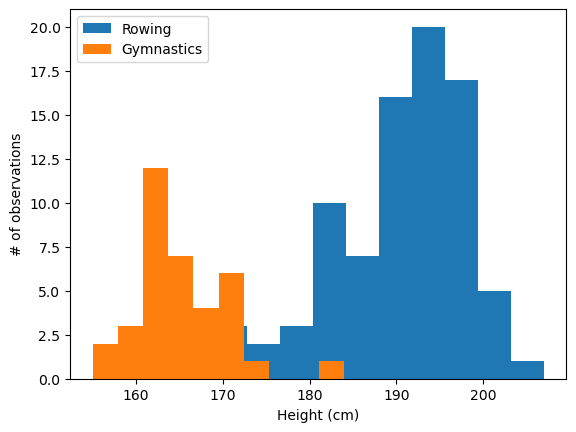

In [14]:
fig, ax = plt.subplots()
ax.hist(mens_rowing["Height"],label="Rowing")
ax.hist(mens_gymnastics["Height"],label = "Gymnastics")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("# of observations")
ax.tick_params
ax.legend()
plt.show()

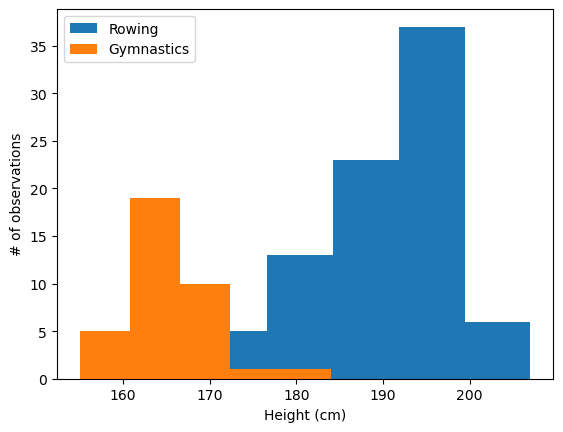

In [15]:
fig, ax = plt.subplots()
ax.hist(mens_rowing["Height"],label="Rowing", bins=5)
ax.hist(mens_gymnastics["Height"],label = "Gymnastics", bins=5)
ax.set_xlabel("Height (cm)")
ax.set_ylabel("# of observations")
ax.tick_params
ax.legend()
plt.show()

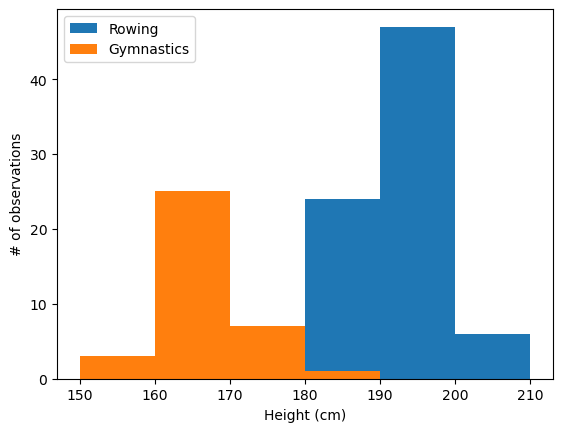

In [16]:
fig, ax = plt.subplots()
ax.hist(mens_rowing["Height"],label="Rowing", bins=range(150,220,10))
ax.hist(mens_gymnastics["Height"],label = "Gymnastics", bins=range(150,220,10))
ax.set_xlabel("Height (cm)")
ax.set_ylabel("# of observations")
ax.tick_params
ax.legend()
plt.show()

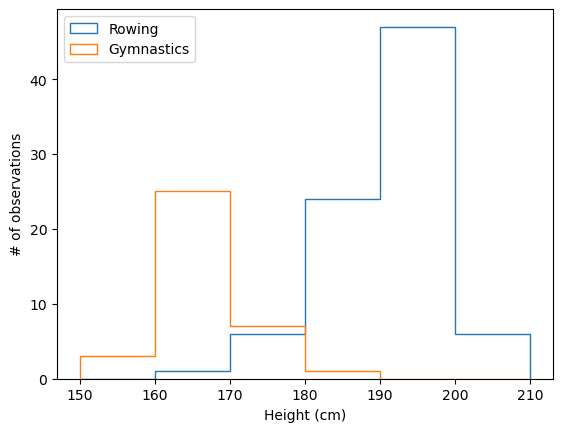

In [17]:
fig, ax = plt.subplots()
ax.hist(mens_rowing["Height"],label="Rowing", bins=range(150,220,10),histtype="step")
ax.hist(mens_gymnastics["Height"],label = "Gymnastics", bins=range(150,220,10),histtype="step")
ax.set_xlabel("Height (cm)")
ax.set_ylabel("# of observations")
ax.tick_params
ax.legend()
plt.show()

# Statistical Plotting

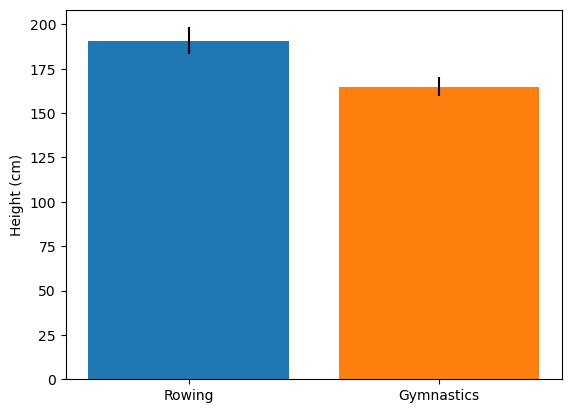

In [18]:
# Ex. For a bar chart
fig, ax = plt.subplots()

def mean_bar_with_error(label, data, variable):
    ax.bar(label, data[variable].mean(), yerr=data[variable].std())

mean_bar_with_error("Rowing", mens_rowing, "Height")
mean_bar_with_error("Gymnastics", mens_gymnastics, "Height")

ax.set_ylabel("Height (cm)")
plt.show()

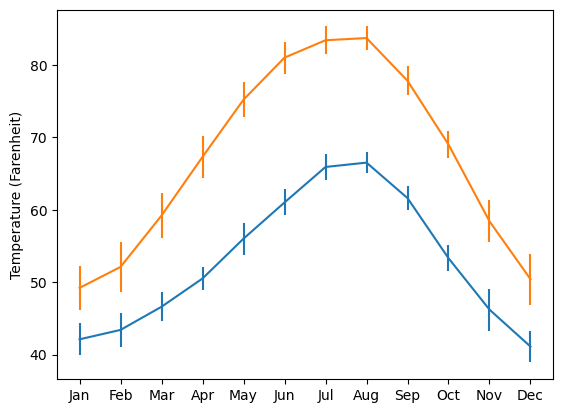

In [22]:
# Ex. For a line plot
fig, ax = plt.subplots()
def line_with_error(data, x, y, error_var):
    ax.errorbar(data[x], data[y], yerr=data[error_var])

line_with_error(seattle_weather, "MONTH", "MLY-TAVG-NORMAL", "MLY-TAVG-STDDEV")
line_with_error(austin_weather, "MONTH", "MLY-TAVG-NORMAL", "MLY-TAVG-STDDEV")

ax.set_ylabel("Temperature (Farenheit)")

plt.show()

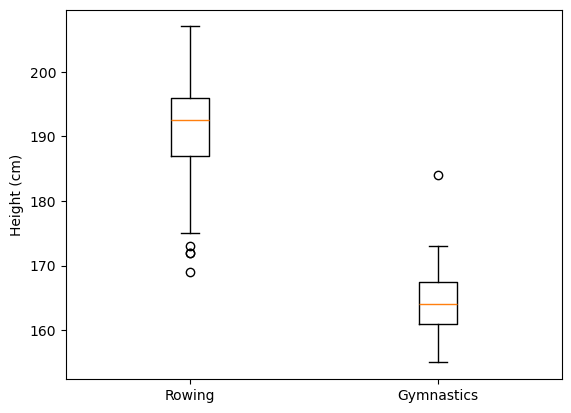

In [26]:
# Box Plots
fig, ax = plt.subplots()

ax.boxplot([mens_rowing["Height"],mens_gymnastics["Height"]])
ax.set_xticklabels(["Rowing","Gymnastics"])
ax.set_ylabel("Height (cm)")
plt.show()

# Scatter Plots (Bivariate Comparisons)

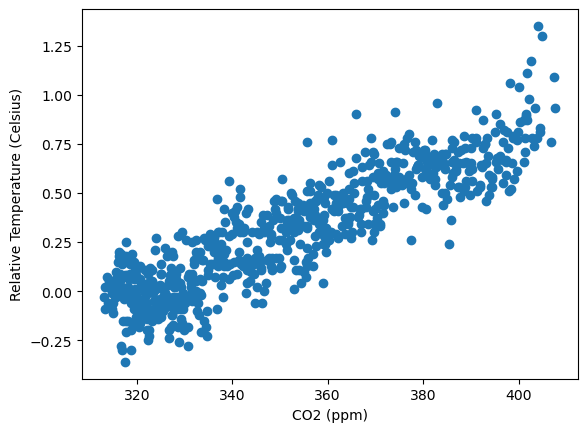

In [27]:
fig, ax = plt.subplots()
ax.scatter(climate_change["co2"], climate_change["relative_temp"])
ax.set_xlabel("CO2 (ppm)")
ax.set_ylabel("Relative Temperature (Celsius)")
plt.show()

## Customizing scatter plots

C:\Users\lucfi\AppData\Local\Temp\ipykernel_23288\1069214538.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eighties["color"]="red"
C:\Users\lucfi\AppData\Local\Temp\ipykernel_23288\1069214538.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eighties["label"]="eighties"
C:\Users\lucfi\AppData\Local\Temp\ipykernel_23288\1069214538.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats i

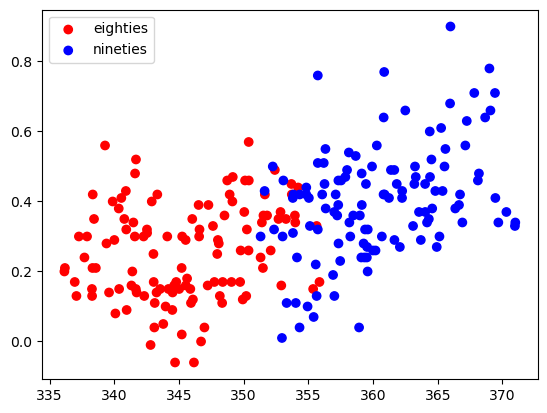

In [31]:
eighties = climate_change["1980-01-01":"1989-12-31"]
eighties["color"]="red"
eighties["label"]="eighties"
nineties = climate_change["1990-01-01":"1999-12-31"]
nineties["color"]="blue"
nineties["label"]="nineties"
fig, ax = plt.subplots()

for decade in [eighties, nineties]:
    ax.scatter(decade["co2"], decade["relative_temp"], color=decade["color"], label=decade["label"][0])

ax.legend()
plt.show()

## Encoding a third variable by color
- use the "c" keyword argument

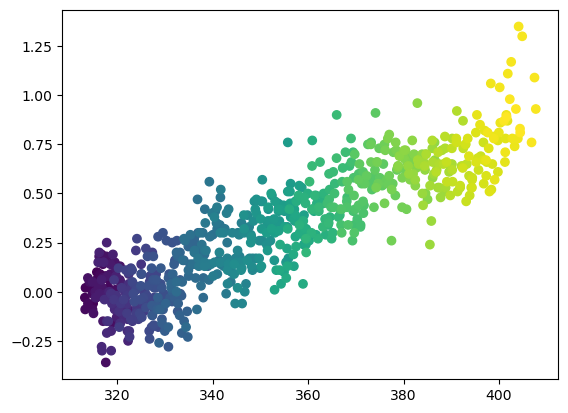

In [33]:
fig, ax= plt.subplots()
ax.scatter(climate_change["co2"], climate_change["relative_temp"], c=climate_change.index)
plt.show()